In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import platform
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

sklearn.set_config(display="text")

# 1. 운영체제별 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin': # Mac OS
    plt.rc('font', family='AppleGothic')
else: # Linux (Colab 등)
    plt.rc('font', family='NanumBarunGothic')

 
# 2. 마이너스 기호(-) 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

## 소셜 광고 데이터 셋
[소셜 광고 데이터셋 링크](https://www.kaggle.com/datasets/akram24/social-network-ads?resource=download)

### 소셜 광고 데이터 셋 컬럼
| 컬럼명 (Column) | 데이터 타입 | 설명 (Description) |
| :--- | :--- | :--- |
| **User ID** | 정수형 (Int) | 유저 고유 식별 번호 (학습 시 제외) |
| **Gender** | 문자형 (String) | 유저의 성별 (Male / Female) |
| **Age** | 정수형 (Int) | 유저의 나이 |
| **EstimatedSalary** | 정수형 (Int) | 유저의 추정 연봉 |
| **Purchased** | 정수형 (Int) | 광고 물건 구매 여부 (0: 미구매, 1: 구매)|

In [2]:
base_path = r"C:\kdt_0900_hhj\ml\resource\dataset"
file_name = r"social_ads.csv"
file_path = os.path.join(base_path,file_name)

In [3]:
df = pd.read_csv(file_path)
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


## 1단계, 데이터 전처리

In [4]:
# User ID: 삭제
# 수치형: Age, EstimatedSalary
# 분류형: User ID, Gender, Purchased

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   User ID          400 non-null    int64
 1   Gender           400 non-null    str  
 2   Age              400 non-null    int64
 3   EstimatedSalary  400 non-null    int64
 4   Purchased        400 non-null    int64
dtypes: int64(4), str(1)
memory usage: 15.8 KB


In [5]:
df.describe()

,User ID,Age,EstimatedSalary,Purchased
count,4.000000e+02,400.000000,400.000000,400.000000
mean,1.569154e+07,37.655000,69742.500000,0.357500
std,7.165832e+04,10.482877,34096.960282,0.479864
min,1.556669e+07,18.000000,15000.000000,0.000000
25%,1.562676e+07,29.750000,43000.000000,0.000000
50%,1.569434e+07,37.000000,70000.000000,0.000000
75%,1.575036e+07,46.000000,88000.000000,1.000000
max,1.581524e+07,60.000000,150000.000000,1.000000


In [6]:
ads_df = df.drop("User ID", axis=1)
ads_df.head()

,Gender,Age,EstimatedSalary,Purchased
0,Male,19,19000,0
1,Male,35,20000,0
2,Female,26,43000,0
3,Female,27,57000,0
4,Male,19,76000,0


In [7]:
ads_df["Purchased"].value_counts()

Purchased
0    257
1    143
Name: count, dtype: int64

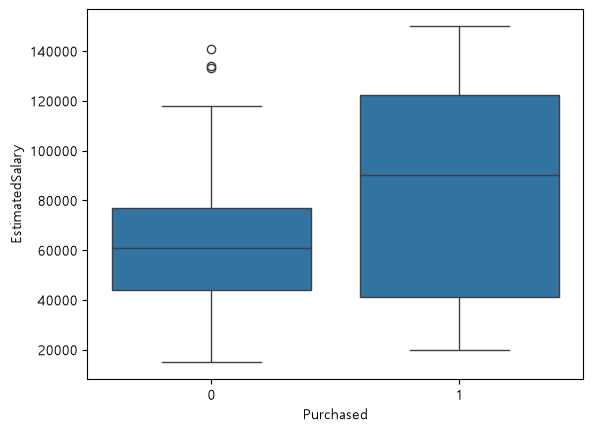

In [8]:
sns.boxplot(ads_df, x="Purchased", y="EstimatedSalary")
plt.show()

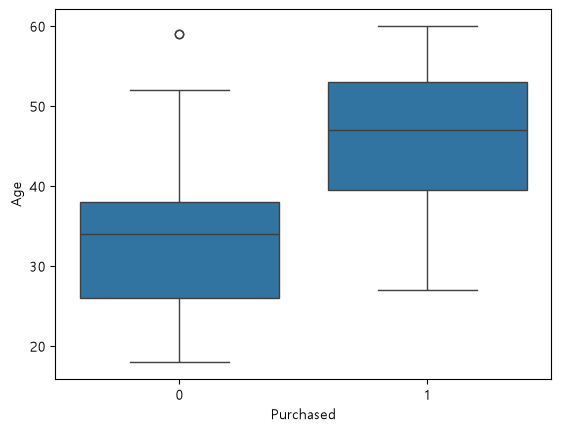

In [9]:
sns.boxplot(ads_df, x="Purchased", y="Age")
plt.show()
# 나이가 많은 사람들이 구매를 많이 하는것이 보임

In [10]:
ads_df.head(1)
# > 성별을 인코딩 해야할거같음!!

,Gender,Age,EstimatedSalary,Purchased
0,Male,19,19000,0


In [11]:
ads_df = pd.get_dummies(ads_df, columns=["Gender"], dtype=int, drop_first=True)

In [12]:
ads_df.head()

,Age,EstimatedSalary,Purchased,Gender_Male
0,19,19000,0,1
1,35,20000,0,1
2,26,43000,0,0
3,27,57000,0,0
4,19,76000,0,1


In [13]:
X = ads_df.drop("Purchased", axis=1)
print(X.head())
y = ads_df["Purchased"]
print(y.head())

   Age  EstimatedSalary  Gender_Male
0   19            19000            1
1   35            20000            1
2   26            43000            0
3   27            57000            0
4   19            76000            1
0    0
1    0
2    0
3    0
4    0
Name: Purchased, dtype: int64


## 데이터 누수
- 데이터 셋을 나누고 스케일링을 해야하는 이유 -> 데이터셋을 나누기 전에 전체 데이터를 스케일링하면
  모델 학습 전에 학습시 절대 보면 안되는 테스트 데이터의 평균과 숫자들이 훈련 데이터셋에 야금야금 스며들어서 데이터 누수가 발생한다.

In [14]:
# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2026, stratify=y)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(320, 3) (80, 3) (320,) (80,)


In [15]:
# 표준화
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

## 2단계, 모델 준비

In [16]:
# salary 연봉 데이터
X_train_salary = X_train_scaled[:, [1]]
X_test_salary = X_test_scaled[:, [1]]

In [17]:
# 선형희귀 모델(weight * x) + bias
# weight: 가중치
# bias: 절편
lr = LinearRegression()

In [18]:
lr.fit(X_train_salary, y_train)

LinearRegression()

In [19]:
print(f"선형 모델의 정확도: {lr.score(X_train_salary, y_train)}")

선형 모델의 정확도: 0.1408930349620512


## 결론 : 쓰레기모델임

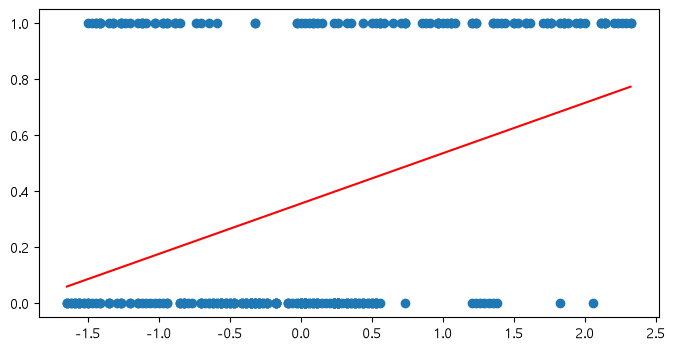

In [20]:
plt.figure(figsize=(8,4))
plt.scatter(X_train_salary, y_train)
x_line = np.linspace(X_train_salary.min(), X_train_salary.max(), 100).reshape(-1,1)
y_line = lr.predict(x_line)
plt.plot(x_line, y_line, color="red")
plt.show()

## 모델준비

In [21]:
lr = LogisticRegression()

## 모델학습

In [22]:
lr.fit(X_train_scaled, y_train)

LogisticRegression()

In [23]:
y_pred = lr.predict(X_test_scaled)
y_pred

array([1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0,
       1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0])

## 모델 평가
<img src="https://blog.kakaocdn.net/dna/beQKaR/btsQVxmfALT/AAAAAAAAAAAAAAAAAAAAAEN8Msuz4492U5M2pBZKQ2RtjEOY5OdH6q0btxI5Uurb/img.png?credential=yqXZFxpELC7KVnFOS48ylbz2pIh7yKj8&expires=1790780399&allow_ip=&allow_referer=&signature=7GgzV35irLeFkyH%2BGmsM6uW65LQ%3D" />

## 과적합(overfitting)
- 머신러닝 과적합은 모델이 학습 데이터에만 지나치게 최적화되는 현상을 의미합니다.
  현재 데이터셋에 지나치게 맞춰지게 되면, 새로운 데이터가 들어왔을 때 예측 능력이 크게 떨어질 수 있습니다.
  이런 현상을 과적합이라고 합니다.

In [24]:
print(f"훈련 데이터 점수 : {lr.score(X_train_scaled, y_train)}")
print(f"테스트 데이터 점수 : {accuracy_score(y_pred, y_test)}")

훈련 데이터 점수 : 0.853125
테스트 데이터 점수 : 0.7875


In [25]:
lr.coef_[0]

array([2.39487483, 1.16153043, 0.37388932])

In [26]:
coef_df = pd.DataFrame({
    "Features": X_train.columns,
    "Coef": lr.coef_[0]
}).sort_values(by="Coef", ascending=False)

coef_df

,Features,Coef
0,Age,2.394875
1,EstimatedSalary,1.161530
2,Gender_Male,0.373889


In [27]:
"""
    소셜에서 상품을 구매할 때에는 연봉보다는 나이가 구매할 때 영향을 많이 끼친 것으로 파악된다.
"""
None

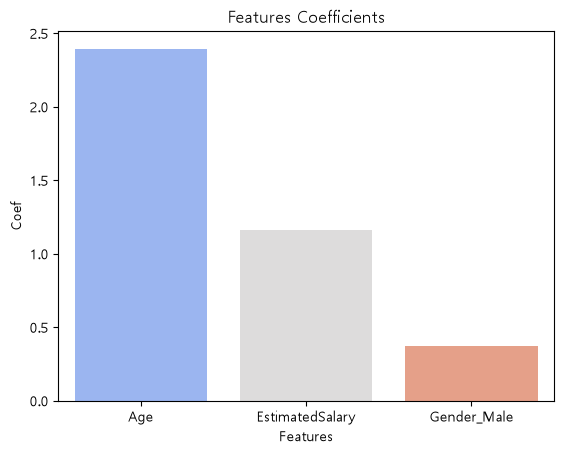

In [28]:
sns.barplot(coef_df, x="Features", y="Coef",hue="Features", palette="coolwarm")
plt.title("Features Coefficients")
plt.show()

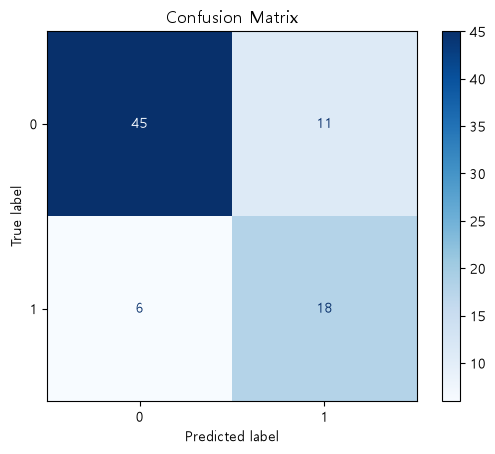

In [29]:
cm = confusion_matrix(y_pred, y_test)
display = ConfusionMatrixDisplay(confusion_matrix=cm)
display.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

# 대학원 합격 예측 데이터 셋
[대학원 합격 예측 데이터셋 링크](https://www.kaggle.com/datasets/mohansacharya/graduate-admissions)

## 컬럼 상세 설명
| 컬럼명 | 데이터 타입 | 데이터 범위 | 설명 |
| :--- | :--- | :--- | :--- |
| **`Serial No.`** | 정수 (Int) | $1 \sim 500$ | 학생 식별용 고유 번호 |
| **`GRE Score`** | 정수 (Int) | $290 \sim 340$ 점 | 미국 대학원 입학 시험(GRE) 점수 |
| **`TOEFL Score`** | 정수 (Int) | $92 \sim 120$ 점 | 공인 영어 능력 평가(TOEFL) 점수 |
| **`University Rating`** | 정수 (Int) | $1 \sim 5$ 단계 | 지원/출신 대학의 명성 레벨 ($1$: 낮음 $\sim$ $5$: 최고) |
| **`SOP`** | 실수 (Float) | $1.0 \sim 5.0$ 점 | 자기소개서/학업계획서(Statement of Purpose) 점수 |
| **`LOR`** | 실수 (Float) | $1.0 \sim 5.0$ 점 | 교수 추천서(Letter of Recommendation) 점수 |
| **`CGPA`** | 실수 (Float) | $6.80 \sim 9.92$ | 학부 평균 학점 (Cumulative GPA, 10점 만점 기준) |
| **`Research`** | 정수 (Int) | $0$ 또는 $1$ | 학부 연구 참여 및 논문 작성 경험 ($0$: 없음, $1$: 있음) |
| **`Chance of Admit`** | 정수 (Int) | $0$ 또는 $1$ | 합격 1, 불합격 0 |

In [30]:
base_path = r"C:\kdt_0900_hhj\ml\resource\dataset"
file_name = r"admission_predict.csv"
file_path = os.path.join(base_path,file_name)

In [31]:
df = pd.read_csv(file_path)
df.head()

,Unnamed: 0,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,0,1,337,118,4,4.5,4.5,9.65,1,1
1,1,2,324,107,4,4.0,4.5,8.87,1,1
2,2,3,316,104,3,3.0,3.5,8.00,1,0
3,3,4,322,110,3,3.5,2.5,8.67,1,1
4,4,5,314,103,2,2.0,3.0,8.21,0,0


In [32]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         400 non-null    int64  
 1   Serial No.         400 non-null    int64  
 2   GRE Score          400 non-null    int64  
 3   TOEFL Score        400 non-null    int64  
 4   University Rating  400 non-null    int64  
 5   SOP                400 non-null    float64
 6   LOR                400 non-null    float64
 7   CGPA               400 non-null    float64
 8   Research           400 non-null    int64  
 9   Chance of Admit    400 non-null    int64  
dtypes: float64(3), int64(7)
memory usage: 31.4 KB


In [33]:
df.describe()

,Unnamed: 0,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,199.500000,200.500000,316.807500,107.410000,3.087500,3.400000,3.452500,8.598925,0.547500,0.450000
std,115.614301,115.614301,11.473646,6.069514,1.143728,1.006869,0.898478,0.596317,0.498362,0.498117
min,0.000000,1.000000,290.000000,92.000000,1.000000,1.000000,1.000000,6.800000,0.000000,0.000000
25%,99.750000,100.750000,308.000000,103.000000,2.000000,2.500000,3.000000,8.170000,0.000000,0.000000
50%,199.500000,200.500000,317.000000,107.000000,3.000000,3.500000,3.500000,8.610000,1.000000,0.000000
75%,299.250000,300.250000,325.000000,112.000000,4.000000,4.000000,4.000000,9.062500,1.000000,1.000000
max,399.000000,400.000000,340.000000,120.000000,5.000000,5.000000,5.000000,9.920000,1.000000,1.000000


In [34]:
drop_columns = ["Serial No.","Unnamed: 0"]
ap_df = df.drop(drop_columns, axis=1)
ap_df

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,337,118,4,4.5,4.5,9.65,1,1
1,324,107,4,4.0,4.5,8.87,1,1
2,316,104,3,3.0,3.5,8.00,1,0
3,322,110,3,3.5,2.5,8.67,1,1
4,314,103,2,2.0,3.0,8.21,0,0
...,...,...,...,...,...,...,...,...
395,324,110,3,3.5,3.5,9.04,1,1
396,325,107,3,3.0,3.5,9.11,1,1
397,330,116,4,5.0,4.5,9.45,1,1
398,312,103,3,3.5,4.0,8.78,0,0


In [35]:
# 상관관계 확인
corr_matrix = ap_df.corr(numeric_only=True)
corr_matrix

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
GRE Score,1.000000,0.835977,0.668976,0.612831,0.557555,0.833060,0.580391,0.686138
TOEFL Score,0.835977,1.000000,0.695590,0.657981,0.567721,0.828417,0.489858,0.672465
University Rating,0.668976,0.695590,1.000000,0.734523,0.660123,0.746479,0.447783,0.638983
SOP,0.612831,0.657981,0.734523,1.000000,0.729593,0.718144,0.444029,0.612152
LOR,0.557555,0.567721,0.660123,0.729593,1.000000,0.670211,0.396859,0.557481
CGPA,0.833060,0.828417,0.746479,0.718144,0.670211,1.000000,0.521654,0.737307
Research,0.580391,0.489858,0.447783,0.444029,0.396859,0.521654,1.000000,0.519441
Chance of Admit,0.686138,0.672465,0.638983,0.612152,0.557481,0.737307,0.519441,1.000000


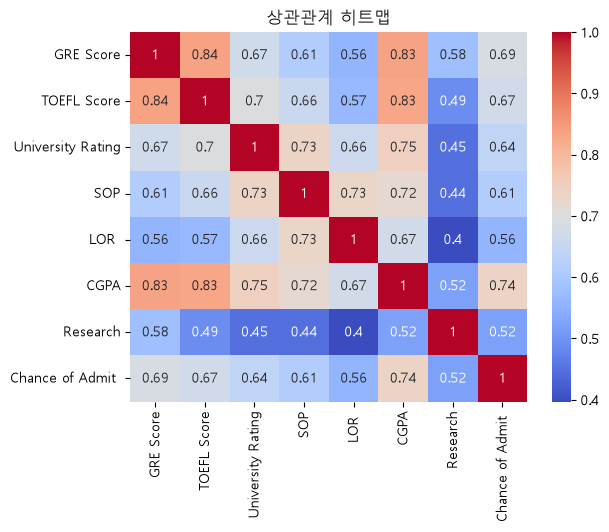

In [36]:
sns.heatmap(corr_matrix, cmap="coolwarm", annot=True)
plt.title("상관관계 히트맵")
plt.show()

In [37]:
# 데이터 분할
X = ap_df.drop("Chance of Admit ", axis=1)
print(X.head())
y = ap_df["Chance of Admit "]
print(y.head())

   GRE Score  TOEFL Score  University Rating  SOP  LOR   CGPA  Research
0        337          118                  4  4.5   4.5  9.65         1
1        324          107                  4  4.0   4.5  8.87         1
2        316          104                  3  3.0   3.5  8.00         1
3        322          110                  3  3.5   2.5  8.67         1
4        314          103                  2  2.0   3.0  8.21         0
0    1
1    1
2    0
3    1
4    0
Name: Chance of Admit , dtype: int64


In [38]:
#데이터 나누기
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2026, stratify=y)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(320, 7) (80, 7) (320,) (80,)


In [39]:
scaler = StandardScaler()

#표준화
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled

array([[ 1.04626087,  1.09713431,  1.65158064, ...,  1.68662152,
         0.98268421,  0.95118973],
       [ 1.98672008,  2.10987368,  1.65158064, ...,  1.13306369,
         2.1903998 ,  0.95118973],
       [-0.3216798 , -0.25318484, -0.97344819, ..., -1.63472547,
        -0.29212669, -1.05131497],
       ...,
       [ 0.27679424, -0.75955453, -0.09843858, ..., -0.52760981,
        -1.51661611, -1.05131497],
       [-1.17664272, -0.42197474,  1.65158064, ...,  1.13306369,
         0.07689752, -1.05131497],
       [-0.3216798 , -0.75955453, -0.09843858, ...,  0.57950586,
         0.24463579, -1.05131497]], shape=(320, 7))

In [40]:
# 모델
lr2 = LogisticRegression()

In [41]:
lr2.fit(X_train_scaled, y_train)

LogisticRegression()

In [42]:
# 예측 레츠고
y_pred = lr2.predict(X_test_scaled)
y_pred

array([1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0,
       1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0])

In [43]:
print(y_test[:10])
print(y_pred[:10])

46     1
342    0
294    0
118    0
78     0
219    0
155    1
329    0
247    0
23     1
Name: Chance of Admit , dtype: int64
[1 0 0 0 0 0 0 0 0 1]


In [44]:
# 평가

train_score = lr2.score(X_train_scaled, y_train)
test_score = lr2.score(X_test_scaled, y_test)

print(f"훈련 데이터 정확도 점수 : {train_score:.2f}")
print(f"테스트 데이터 정확도 점수 : {test_score:.2f}")

훈련 데이터 정확도 점수 : 0.89
테스트 데이터 정확도 점수 : 0.89


In [45]:
lr2.coef_[0]

array([0.66240298, 0.32488882, 0.50617208, 0.62748009, 0.14616093,
       1.75286373, 0.35710735])

In [46]:
# 우리 모델에서 어떤 변수가 예측에 어떤 방향으로 얼마나 영향을 주는지 한눈에 보기
coef_df = pd.DataFrame({
    "Features": X_train.columns,
    "Coef": lr2.coef_[0]
}).sort_values(by="Coef", ascending=False)

coef_df

,Features,Coef
5,CGPA,1.752864
0,GRE Score,0.662403
3,SOP,0.627480
2,University Rating,0.506172
6,Research,0.357107
1,TOEFL Score,0.324889
4,LOR,0.146161


In [47]:
from sklearn.metrics import RocCurveDisplay

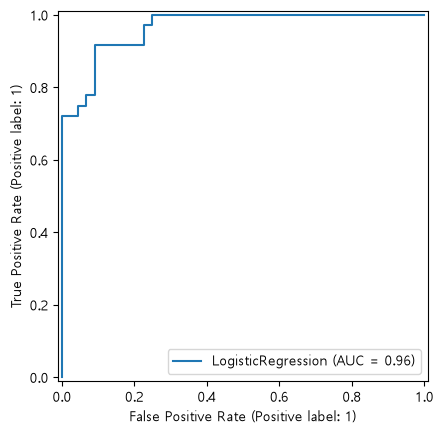

In [48]:
RocCurveDisplay.from_estimator(lr2, X_test_scaled, y_test)

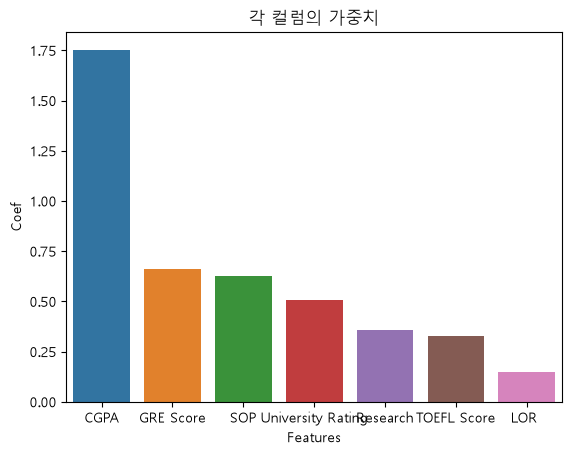

In [49]:
sns.barplot(coef_df, x="Features", y="Coef", hue="Features")
plt.title("각 컬럼의 가중치")
plt.show()

In [ ]:
## 쌤풀이

In [55]:
drop_columns = ["Serial No.","Unnamed: 0"]
admission_df = df.drop(drop_columns, axis=1)
admission_df

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,337,118,4,4.5,4.5,9.65,1,1
1,324,107,4,4.0,4.5,8.87,1,1
2,316,104,3,3.0,3.5,8.00,1,0
3,322,110,3,3.5,2.5,8.67,1,1
4,314,103,2,2.0,3.0,8.21,0,0
...,...,...,...,...,...,...,...,...
395,324,110,3,3.5,3.5,9.04,1,1
396,325,107,3,3.0,3.5,9.11,1,1
397,330,116,4,5.0,4.5,9.45,1,1
398,312,103,3,3.5,4.0,8.78,0,0


In [58]:
admission_df = df.drop(["Unnamed: 0", "Serial No."], axis=1)
admission_df.columns = ['GRE Score', 'TOEFL Score', 'University Rating', 'SOP', 'LOR', 'CGPA', 'Research', 'Target']

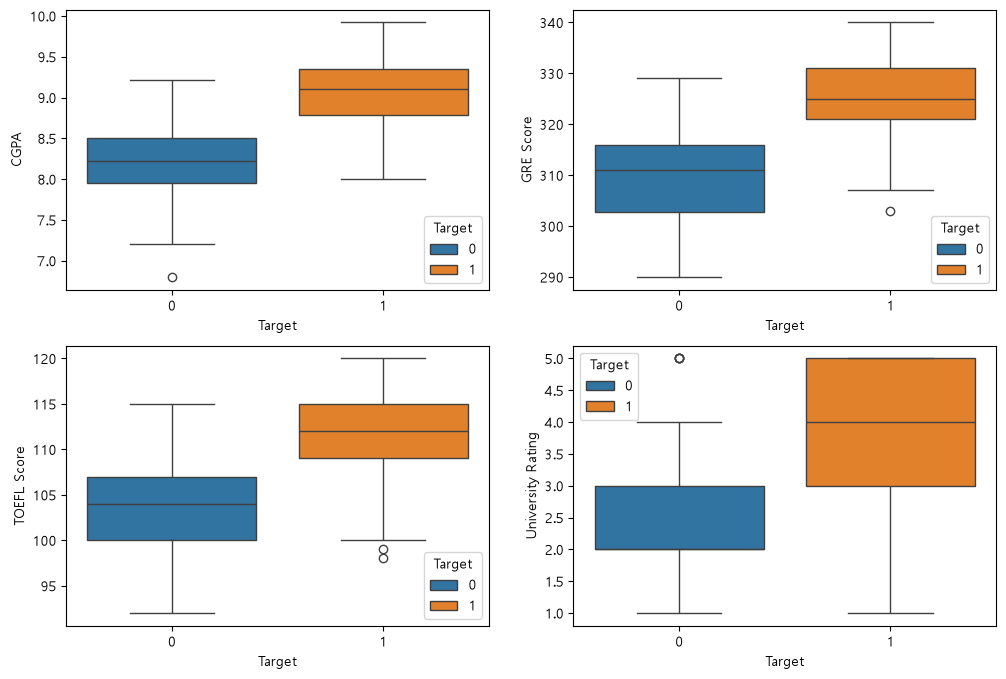

In [59]:
features = ["CGPA","GRE Score","TOEFL Score","University Rating"]

plt.figure(figsize=(12,8))
for i, feature in enumerate(features, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(admission_df, x="Target", y=feature, hue="Target")

plt.show()

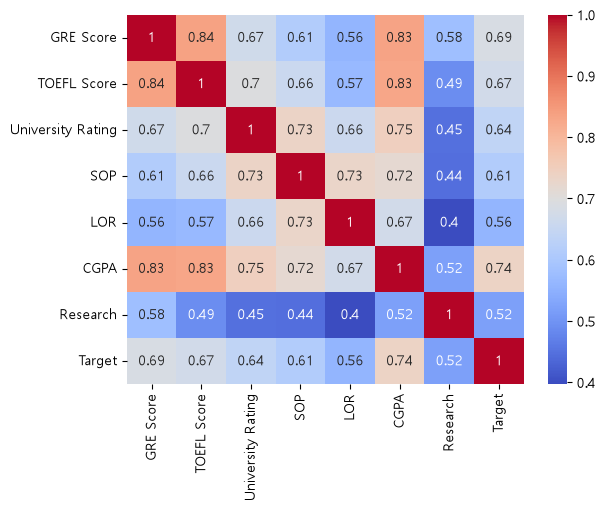

In [63]:
#상관관계 영향력보기
corr = admission_df.corr()

#시각화해서 보기
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

In [66]:
X = admission_df.drop("Target", axis=1)
X.head()
y = admission_df["Target"]
y.head()

0    1
1    1
2    0
3    1
4    0
Name: Target, dtype: int64

In [64]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [70]:
vit = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vit)
print(X.columns)

[np.float64(4.615516166781608), np.float64(4.288959013746899), np.float64(2.9196056618253414), np.float64(3.075503721954348), np.float64(2.431258484869441), np.float64(5.207402545736424), np.float64(1.5433119011502867)]
Index(['GRE Score', 'TOEFL Score', 'University Rating', 'SOP', 'LOR', 'CGPA',
       'Research'],
      dtype='str')


In [71]:
# 데이터 분할

train_test_split(X, y, test_size=0.2, random_state=2026, stratify=y)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(320, 7) (80, 7) (320,) (80,)


In [74]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error

# mean_squared_error > mse : 값마다의 (확률선상)선과의 거리(잔차)를 예측하는??? 평가하는???

In [ ]:
## 데이터 표준화

scaler = StandardScaler()

In [81]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 규제(regularization)
- 머신러닝 모델이 train 세트를 너무 과도하게 학습하지 못하도록 훼방하는 것
- 선형회귀 모델의 경우 특성에 곱해지는 계수 또는 기울기의 크기를 작게 만드는 일이다.
- 쉽게 말하자면 선형회귀 모델의 성능을 끌어올리기 위한 방법이다.
  
#### 1) 릿지(ridge)
- 계수를 제곱한 값을 기준으로 규제를 적용한다. (일반적으로 선호)
- 조금 넘을 때는 벌금이 적지만, 과속이 심해질수록 벌금이 제곱으로 폭발하도록 설계된다.  
  즉, 작은 값으로 연산하여 값이 폭발하는 것을 방지함.
- 예를 들어 $z = (2.5 \times 100) + b = 250 + b$를
- $z = (0.008 \times 100) + b = 0.8 + b$


#### 2) 라쏘(lasso)
- 계수의 절댓값을 기준으로 규제를 적용한다. 영향을 주지 않는 가중치는 과감하게 빼버림 (가중치가 작든 크든 줄어드는 비율이 일정)
- $z = $$z = w_1 \cdot (\text{연봉}) + w_2 \cdot (\text{나이}) + w_3 \cdot (\text{성별}) + b$$
- $z = $$z = w_1 \cdot (\text{연봉}) + 0 \cdot (\text{나이}) + 0 \cdot (\text{성별}) + b$$

In [83]:
# 학습?
models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.01)
}

result = []
coef_df = pd.DataFrame(index=X.columns)

for name, model in models.items():
    # 학습
    model.fit(X_train_scaled, y_train)
    # 예측
    y_pred = model.predict(X_test_scaled)
    # 평가
    mse = mean_squared_error(y_test, y_pred)
    # rmse (루트를 씌운mse)
    rmse = np.sqrt(mse)
    y_pred_class = (y_pred >= 0.5).astype(int)
    acc = accuracy_score(y_test, y_pred_class)

    result.append({
        "Model": name,
        "MSE": mse,
        "RMSE": rmse,
        "Accuracy":  acc
    })

    coef_df[name] = model.coef_

In [84]:
result_df = pd.DataFrame(result)
result_df
# accuracy가 왜 80퍼나 나오는가? 알아보자>두칸아래로

,Model,MSE,RMSE,Accuracy
0,LinearRegression,0.101292,0.318264,0.8625
1,Ridge,0.101213,0.318139,0.8625
2,Lasso,0.101332,0.318326,0.8875


In [85]:
coef_df.sort_values(by="LinearRegression", ascending=False)

,LinearRegression,Ridge,Lasso
CGPA,0.170626,0.168599,0.169111
GRE Score,0.076086,0.076236,0.075305
University Rating,0.069660,0.069725,0.066634
Research,0.064450,0.064335,0.058810
SOP,0.055002,0.054779,0.048769
TOEFL Score,0.009755,0.010982,0.008198
LOR,-0.004585,-0.003801,0.000000


In [95]:
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

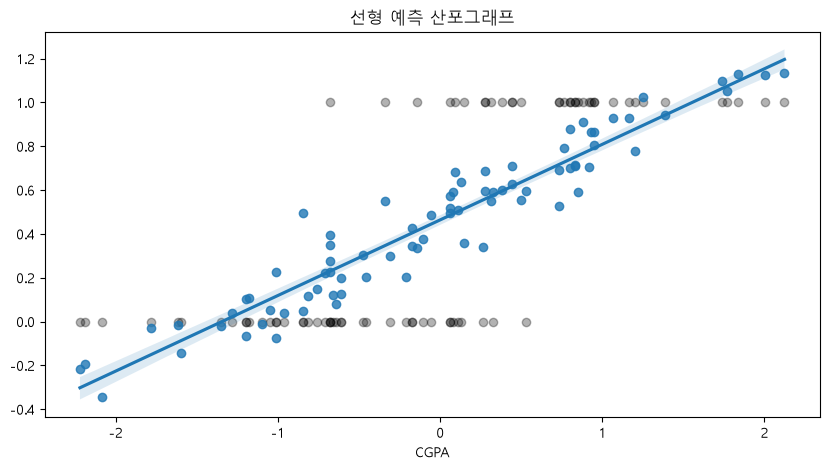

In [104]:
# accuracy가 왜 80퍼나 나오는가???? > 그래프로 알아보자?
plt.figure(figsize=(10, 5))
plt.scatter(X_test_scaled_df["CGPA"], y_test, color="black", alpha=0.3, label="Actual")
sns.regplot(x=X_test_scaled_df["CGPA"], y=model.predict(X_test_scaled))

plt.title("선형 예측 산포그래프")
plt.show()

#위쪽이 합격데이터, 아래가 불합격데이터..
# 라인을 그렷을때 위에잇는애들은 합격 아래는 불합격
# 못쓰는 그래프,못쓰는 데이터라네요...이건 운이좋아서 잘 맞았던거임!!!?

In [105]:
lr = LogisticRegression()

In [107]:
lr.fit(X_train_scaled, y_train)

LogisticRegression()

In [108]:
y_pred = lr.predict(X_test_scaled)
y_pred

array([1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0,
       1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0])

In [120]:
y_prob = lr.predict_proba(X_test_scaled)[:, 1]

#확률
y_prob_percent = y_prob * 100

y_prob_percent


for i, proba in enumerate(y_prob_percent[:20], 1):
    print(f"샘플 {i}번의 합격 확률: {proba:.2f}%")

샘플 1번의 합격 확률: 98.86%
샘플 2번의 합격 확률: 5.62%
샘플 3번의 합격 확률: 6.88%
샘플 4번의 합격 확률: 0.09%
샘플 5번의 합격 확률: 0.24%
샘플 6번의 합격 확률: 14.38%
샘플 7번의 합격 확률: 24.86%
샘플 8번의 합격 확률: 0.24%
샘플 9번의 합격 확률: 6.15%
샘플 10번의 합격 확률: 99.88%
샘플 11번의 합격 확률: 80.96%
샘플 12번의 합격 확률: 0.35%
샘플 13번의 합격 확률: 96.18%
샘플 14번의 합격 확률: 99.66%
샘플 15번의 합격 확률: 98.39%
샘플 16번의 합격 확률: 89.61%
샘플 17번의 합격 확률: 75.23%
샘플 18번의 합격 확률: 0.29%
샘플 19번의 합격 확률: 52.76%
샘플 20번의 합격 확률: 94.89%


In [123]:
acc = accuracy_score(y_test, y_pred)
acc

print(f"로지스틱 회귀 정확도: {acc:.2f}")

로지스틱 회귀 정확도: 0.89


In [125]:
coef_df = pd.DataFrame({
    "Features": X_train.columns,
    "Coef": lr.coef_[0]
}).sort_values(by="Coef", ascending=False)
#  ascending=False) : 내림차수 정렬

coef_df

,Features,Coef
5,CGPA,1.752864
0,GRE Score,0.662403
3,SOP,0.627480
2,University Rating,0.506172
6,Research,0.357107
1,TOEFL Score,0.324889
4,LOR,0.146161


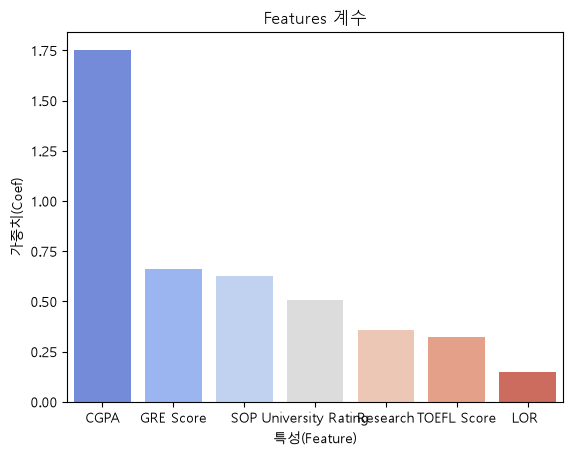

In [128]:
sns.barplot(coef_df, x="Features", y="Coef", palette="coolwarm", hue="Features")
plt.title("Features 계수") # 계수: 얼마나많이 영향을 끼쳤는가
plt.xlabel("특성(Feature)")
plt.ylabel("가중치(Coef)")
plt.show()

In [130]:
print(classification_report(y_test, y_pred))
#모델 평가 (과적합되었는가? 등등)

              precision    recall  f1-score   support

           0       0.93      0.86      0.89        44
           1       0.85      0.92      0.88        36

    accuracy                           0.89        80
   macro avg       0.89      0.89      0.89        80
weighted avg       0.89      0.89      0.89        80

